In [2]:
!pip install -q torch torchvision
!pip install -q diffusers transformers accelerate
!pip install -q datasets matplotlib pillow numpy tqdm
!pip install -q clean-fid

print("✓ Packages installed!")

✓ Packages installed!


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from diffusers import DDPMScheduler, UNet2DModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n{'='*70}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("="*70)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.



Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
print("Loading CelebA dataset...\n")
dataset = load_dataset("nielsr/CelebA-faces")

print(f"Dataset loaded: {len(dataset['train'])} total images")
print(f"Using: 2,700 for training, 300 for testing")

Loading CelebA dataset...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/463M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/463M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/202599 [00:00<?, ? examples/s]

Dataset loaded: 202599 total images
Using: 2,700 for training, 300 for testing


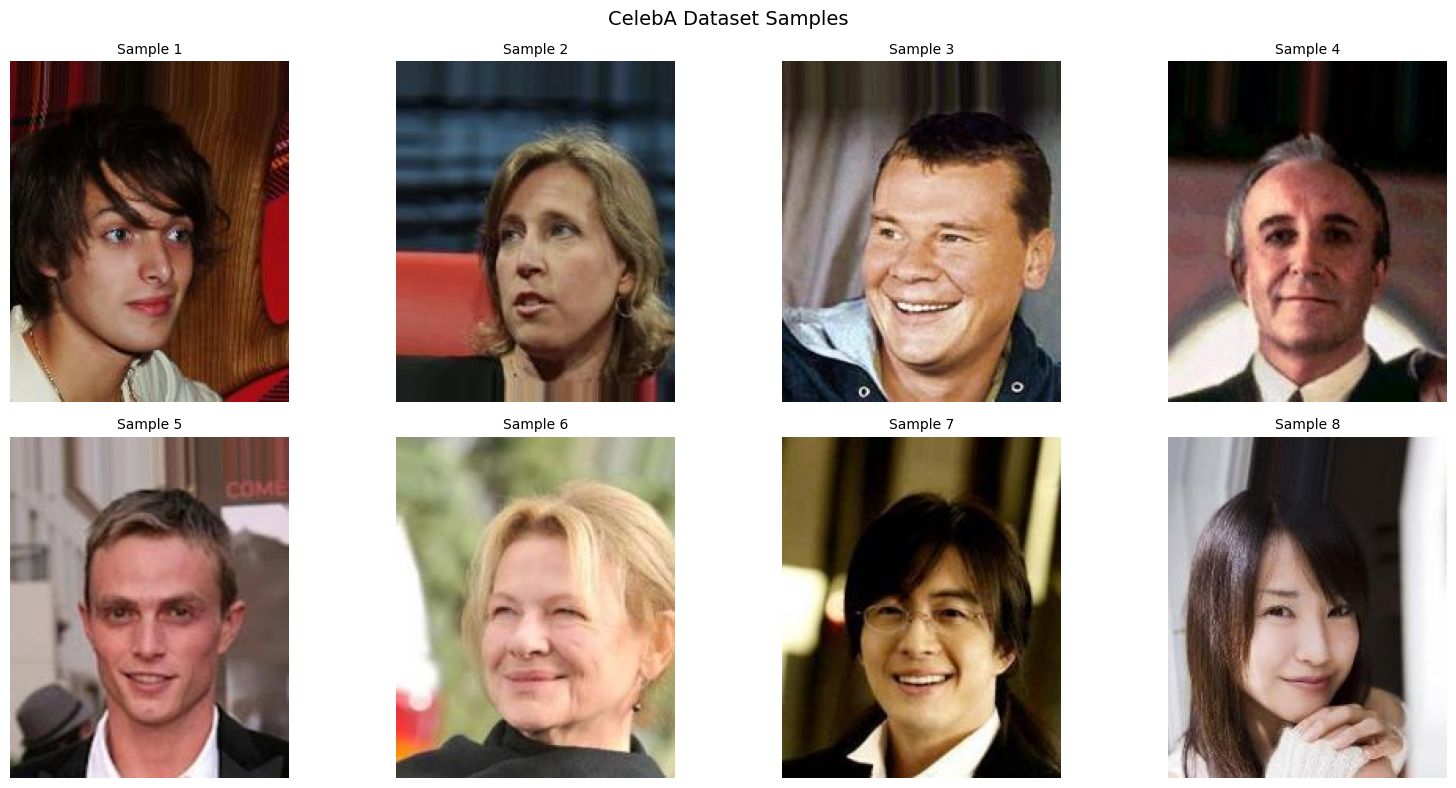

✓ Saved: partb_dataset_samples.png


In [5]:
# Show dataset samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = dataset['train'][idx * 300]['image']
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {idx+1}', fontsize=10)

plt.suptitle('CelebA Dataset Samples', fontsize=14)
plt.tight_layout()
plt.savefig('partb_dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: partb_dataset_samples.png")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Configuration
IMAGE_SIZE = 256
TRAIN_SIZE = 2700
TEST_SIZE = 300
BATCH_SIZE = 8
NUM_EPOCHS = 100
LEARNING_RATE =1e-5
NUM_TIMESTEPS = 1000
RESUME_FROM_CHECKPOINT='/content/drive/MyDrive/checkpoint_epoch_095.pt'
# Create directories
os.makedirs('partb_checkpoints', exist_ok=True)
os.makedirs('partb_samples', exist_ok=True)
os.makedirs('partb_generated', exist_ok=True)
os.makedirs('partb_test_images', exist_ok=True)

print(f"\nConfiguration:")
print(f"  Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Training images: {TRAIN_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")


Configuration:
  Image size: 256×256
  Training images: 2700
  Epochs: 100
  Batch size: 8


In [8]:
# Dataset class
class CelebADataset(Dataset):
    def __init__(self, hf_dataset, start_idx, end_idx, image_size=256):
        self.dataset = hf_dataset
        self.start_idx = start_idx
        self.end_idx = end_idx

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return self.end_idx - self.start_idx

    def __getitem__(self, idx):
        actual_idx = self.start_idx + idx
        image = self.dataset['train'][actual_idx]['image'].convert('RGB')
        return {'pixel_values': self.transform(image)}

# Create datasets
train_dataset = CelebADataset(dataset, 0, TRAIN_SIZE, IMAGE_SIZE)
test_dataset = CelebADataset(dataset, TRAIN_SIZE, TRAIN_SIZE + TEST_SIZE, IMAGE_SIZE)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"\n✓ Data loaders ready")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")


✓ Data loaders ready
  Training batches: 338
  Test batches: 38


In [9]:
# Create U-Net model
model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)
model = model.to(device)

# Noise scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=NUM_TIMESTEPS)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel created: {num_params:,} parameters")


Model created: 106,380,035 parameters


In [10]:
START_EPOCH = 0
losses = []

if RESUME_FROM_CHECKPOINT and os.path.exists(RESUME_FROM_CHECKPOINT):
    checkpoint = torch.load(RESUME_FROM_CHECKPOINT, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    START_EPOCH = checkpoint['epoch']
    print(f"✓ Resumed from epoch {START_EPOCH}, loss was {checkpoint['loss']:.4f}")
else:
    print("✗ No checkpoint found — starting from scratch")

✓ Resumed from epoch 95, loss was 0.0070


In [11]:
# Function to generate face images
@torch.no_grad()
def generate_face_samples(model, noise_scheduler, num_samples=8, device='cuda'):
    model.eval()

    # Start from random noise
    sample = torch.randn(num_samples, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

    # Denoise step by step
    for t in tqdm(noise_scheduler.timesteps, desc="Generating", leave=False):
        noise_pred = model(sample, t).sample
        sample = noise_scheduler.step(noise_pred, t, sample).prev_sample

    # Convert to PIL images
    images = []
    for i in range(num_samples):
        img = sample[i].permute(1, 2, 0).cpu()
        # min-max normalise per image — fixes red/blue colour cast
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = img.clamp(0, 1).numpy()
        img = Image.fromarray((img * 255).astype(np.uint8))
        images.append(img)

    return images


STARTING TRAINING
Epochs: 100


Epoch 96/100:   0%|          | 0/338 [00:00<?, ?it/s]

Epoch 96: Average Loss = 0.0071


Epoch 97/100:   0%|          | 0/338 [00:00<?, ?it/s]

Epoch 97: Average Loss = 0.0079


...

Epoch 99/100:   0%|          | 0/338 [00:00<?, ?it/s]

Epoch 99: Average Loss = 0.0077


Epoch 100/100:   0%|          | 0/338 [00:00<?, ?it/s]

Epoch 100: Average Loss = 0.0068

Generating 8 face samples...


Generating:   0%|          | 0/1000 [00:00<?, ?it/s]

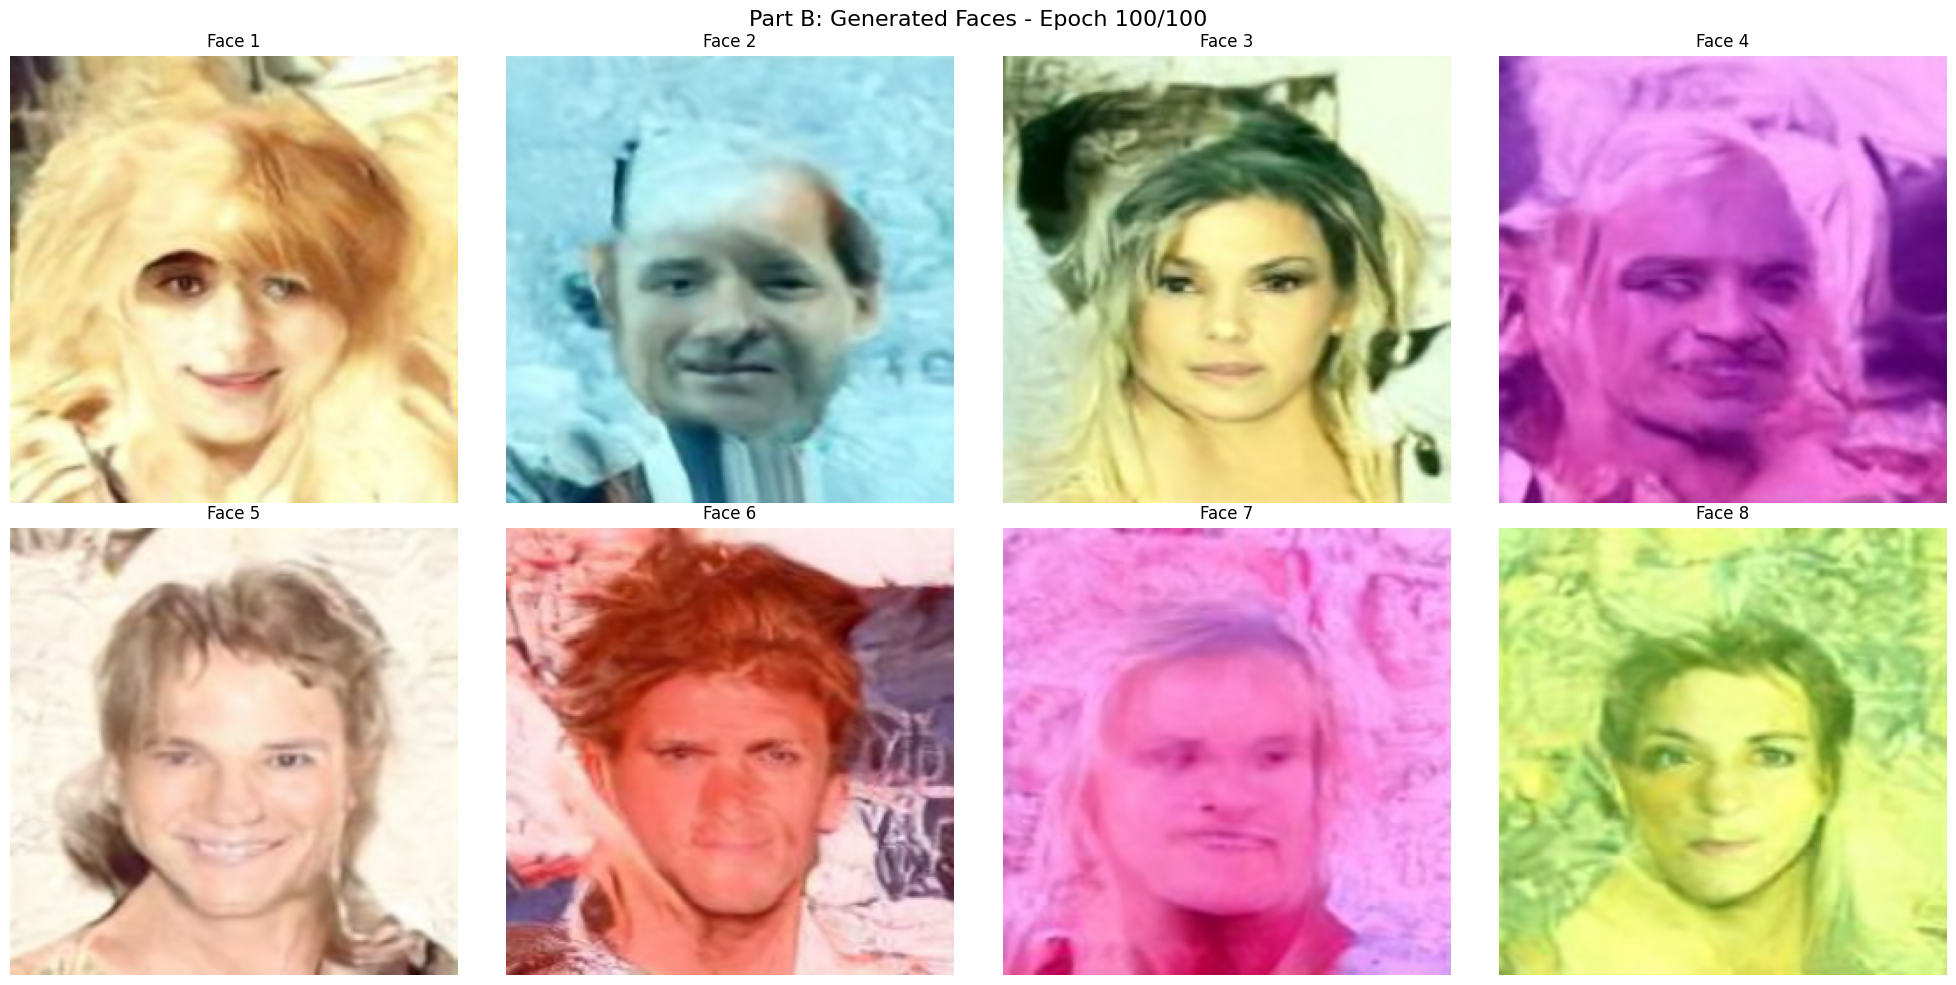

✓ Saved: partb_samples/epoch_100.png

✓ Checkpoint saved: /content/drive/MyDrive/checkpoint_epoch_100.pt

TRAINING COMPLETE!


In [12]:
# Training loop
print(f"\n{'='*70}")
print("STARTING TRAINING")
print("="*70)
print(f"Epochs: {NUM_EPOCHS}")

print("="*70)


for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch in progress_bar:
        clean_images = batch['pixel_values'].to(device)

        # Sample noise
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(
            0, NUM_TIMESTEPS,
            (clean_images.shape[0],), device=device
        ).long()

        # Add noise
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Predict noise
        noise_pred = model(noisy_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Average Loss = {avg_loss:.4f}")

    # Generate face samples every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\nGenerating 8 face samples...")
        face_images = generate_face_samples(model, noise_scheduler, num_samples=8, device=device)

        # Display in 2x4 grid
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        for idx, (ax, img) in enumerate(zip(axes, face_images)):
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f'Face {idx+1}', fontsize=12)

        plt.suptitle(f'Part B: Generated Faces - Epoch {epoch+1}/{NUM_EPOCHS}', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'partb_samples/epoch_{epoch+1:03d}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: partb_samples/epoch_{epoch+1:03d}.png\n")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f"/content/drive/MyDrive/checkpoint_epoch_{epoch+1:03d}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, checkpoint_path)
        print(f"✓ Checkpoint saved: {checkpoint_path}")

print(f"\n{'='*70}")
print("TRAINING COMPLETE!")
print("="*70)

In [17]:
print(f"\n{'='*70}")
print("GENERATING 300 FINAL FACE SAMPLES")
print("="*70)

model.eval()
all_generated_faces = []

batch_size = 10
num_batches = 30

for batch_idx in tqdm(range(num_batches), desc="Generating batches"):
    print(batch_idx)
    with torch.no_grad():
        sample = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

        for t in noise_scheduler.timesteps:
            noise_pred = model(sample, t).sample
            sample = noise_scheduler.step(noise_pred, t, sample).prev_sample

        for i in range(batch_size):
            # Fixed normalisation
            img = sample[i].permute(1, 2, 0).cpu()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            img = img.clamp(0, 1).numpy()
            img = Image.fromarray((img * 255).astype(np.uint8))

            img_idx = batch_idx * batch_size + i
            img.save(f"/content/drive/MyDrive/partb_generated/face_{img_idx:04d}.png")
            all_generated_faces.append(img)

print(f"\n✓ Generated {len(all_generated_faces)} face images")
print(f"✓ Saved to: partb_generated/")


GENERATING 300 FINAL FACE SAMPLES


Generating batches:   0%|          | 0/30 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29

✓ Generated 300 face images
✓ Saved to: partb_generated/


In [18]:
# Save test images
print("Saving test images...")

for idx, batch in enumerate(tqdm(test_loader, desc="Saving test images")):
    images = batch['pixel_values']

    for i, img_tensor in enumerate(images):
        img = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2
        img = np.clip(img, 0, 1)
        img = Image.fromarray((img * 255).astype(np.uint8))

        img_idx = idx * BATCH_SIZE + i
        if img_idx < TEST_SIZE:
            img.save(f"partb_test_images/test_{img_idx:04d}.png")

print(f"✓ Saved {TEST_SIZE} test images")

Saving test images...


Saving test images:   0%|          | 0/38 [00:00<?, ?it/s]

✓ Saved 300 test images


In [19]:
# Compute FID
from cleanfid import fid

print(f"\n{'='*70}")
print("COMPUTING FID SCORE")
print("="*70)

fid_score = fid.compute_fid(
    "partb_test_images",
    "/content/drive/MyDrive/partb_generated/",
    mode="clean",
    num_workers=4
)

print(f"\nFID Score: {fid_score:.2f}")
print("="*70)

# Save FID score
with open('partb_fid_score.txt', 'w') as f:
    f.write(f"Part B: Face Diffusion from Scratch\n")
    f.write(f"FID Score: {fid_score:.2f}\n")
    f.write(f"Test images: {TEST_SIZE}\n")
    f.write(f"Generated images: 300\n")

print("✓ Saved: partb_fid_score.txt")


COMPUTING FID SCORE
compute FID between two folders
Found 300 images in the folder partb_test_images


FID partb_test_images : 100%|██████████| 10/10 [00:04<00:00,  2.10it/s]


Found 300 images in the folder /content/drive/MyDrive/partb_generated/


FID  : 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]



FID Score: 129.42
✓ Saved: partb_fid_score.txt
